In [ ]:
!pip -q install pandas==2.2.2 pillow==11.3.0 scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path

MODEL_ALIAS = "ResNet50"

PROJECT_ROOT = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification")
PREP_ROOT = PROJECT_ROOT / "prepared_data_v1"
CNN_ROOT = PREP_ROOT / "cnn_dataset"

TRAIN_DIR = CNN_ROOT / "train"
VAL_DIR = CNN_ROOT / "val"
TEST_DIR = CNN_ROOT / "test"

MODEL_ROOT = PROJECT_ROOT / "Model" / "CNN_Baselines"
RUN_DIR = MODEL_ROOT / MODEL_ALIAS
REPORT_ROOT = MODEL_ROOT / "reports"

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

print("MODEL_ALIAS:", MODEL_ALIAS)
print("TRAIN_DIR  :", TRAIN_DIR)
print("VAL_DIR    :", VAL_DIR)
print("TEST_DIR   :", TEST_DIR)
print("RUN_DIR    :", RUN_DIR)

assert TRAIN_DIR.exists(), f"Không tìm thấy TRAIN_DIR: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Không tìm thấy VAL_DIR: {VAL_DIR}"
assert TEST_DIR.exists(), f"Không tìm thấy TEST_DIR: {TEST_DIR}"

Mounted at /content/drive
MODEL_ALIAS: ResNet50
TRAIN_DIR  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_dataset/train
VAL_DIR    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_dataset/val
TEST_DIR   : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_dataset/test
RUN_DIR    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50


In [ ]:
import os
import json
import time
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Không bật được memory growth:", e)

ENABLE_MIXED_PRECISION = True

if ENABLE_MIXED_PRECISION and len(gpus) > 0:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
else:
    tf.keras.mixed_precision.set_global_policy("float32")

print("TensorFlow:", tf.__version__)
print("GPU count :", len(gpus))
print("Policy    :", tf.keras.mixed_precision.global_policy())

CLASS_NAMES = ["Anthracnose", "BacterialSpot", "Curl", "Healthy", "RingSpot"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32

BACKBONE_FN = tf.keras.applications.ResNet50
PREPROCESS_FN = tf.keras.applications.resnet50.preprocess_input

STAGE1_EPOCHS = 8
STAGE2_EPOCHS = 15

STAGE1_LR = 1e-4
STAGE2_LR = 1e-5

UNFREEZE_LAST_N = 40
DROPOUT_RATE = 0.40

EARLY_STOPPING_PATIENCE = 5
REDUCE_LR_PATIENCE = 2
REDUCE_LR_FACTOR = 0.3
MIN_LR = 1e-7

FORCE_RETRAIN = False

print("MODEL_ALIAS:", MODEL_ALIAS)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("UNFREEZE_LAST_N:", UNFREEZE_LAST_N)

TensorFlow: 2.19.0
GPU count : 1
Policy    : <DTypePolicy "mixed_float16">
MODEL_ALIAS: ResNet50
IMG_SIZE: 224
BATCH_SIZE: 32
UNFREEZE_LAST_N: 40


In [ ]:
VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(folder):
    folder = Path(folder)
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
    ])

rows = []

for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        n = len(list_images(cls_dir)) if cls_dir.exists() else 0
        rows.append({
            "split": split_name,
            "class_name": cls,
            "num_images": n,
            "class_dir": str(cls_dir),
        })

count_df = pd.DataFrame(rows)
display(count_df)

count_df.to_csv(RUN_DIR / "dataset_count.csv", index=False, encoding="utf-8-sig")

train_counts = {}
for cls in CLASS_NAMES:
    cls_dir = TRAIN_DIR / cls
    train_counts[cls] = len(list_images(cls_dir)) if cls_dir.exists() else 0

total_train = sum(train_counts.values())

class_weights = {}
for idx, cls in enumerate(CLASS_NAMES):
    if train_counts[cls] > 0:
        class_weights[idx] = total_train / (NUM_CLASSES * train_counts[cls])
    else:
        class_weights[idx] = 1.0

print("Train counts:")
print(train_counts)

print("\nClass weights:")
print({CLASS_NAMES[k]: round(v, 4) for k, v in class_weights.items()})

,split,class_name,num_images,class_dir
0,train,Anthracnose,4416,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
1,train,BacterialSpot,320,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
2,train,Curl,254,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
3,train,Healthy,160,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
4,train,RingSpot,2412,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
5,val,Anthracnose,1046,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
6,val,BacterialSpot,69,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
7,val,Curl,54,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
8,val,Healthy,34,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
9,val,RingSpot,510,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...


Train counts:
{'Anthracnose': 4416, 'BacterialSpot': 320, 'Curl': 254, 'Healthy': 160, 'RingSpot': 2412}

Class weights:
{'Anthracnose': 0.3425, 'BacterialSpot': 4.7263, 'Curl': 5.9543, 'Healthy': 9.4525, 'RingSpot': 0.627}


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

def preprocess_train(x, y):
    x = data_augmentation(x, training=True)
    x = PREPROCESS_FN(x)
    return x, y

def preprocess_eval(x, y):
    x = PREPROCESS_FN(x)
    return x, y

def make_datasets():
    common_args = dict(
        labels="inferred",
        label_mode="int",
        class_names=CLASS_NAMES,
        color_mode="rgb",
        image_size=(IMG_SIZE, IMG_SIZE),
        interpolation="bilinear",
        batch_size=BATCH_SIZE,
        seed=SEED,
        verbose=True,
    )

    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        shuffle=True,
        **common_args
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        shuffle=False,
        **common_args
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        shuffle=False,
        **common_args
    )

    train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds = val_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test_ds = test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = make_datasets()

for x, y in train_ds.take(1):
    print("Image batch:", x.shape, x.dtype)
    print("Label batch:", y.shape, y.dtype)

Found 7562 files belonging to 5 classes.
Found 1713 files belonging to 5 classes.
Found 1836 files belonging to 5 classes.
Image batch: (32, 224, 224, 3) <dtype: 'float16'>
Label batch: (32,) <dtype: 'int32'>


In [ ]:
def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def count_history_epochs(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return 0
    try:
        df = pd.read_csv(csv_path)
        return len(df)
    except Exception:
        return 0

def build_classifier():
    backbone = BACKBONE_FN(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(DROPOUT_RATE, name="head_dropout")(x)
    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        dtype="float32",
        name="classifier"
    )(x)

    model = keras.Model(inputs, outputs, name=f"{MODEL_ALIAS}_classifier")
    return model

def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

def find_backbone(model):
    for layer in model.layers:
        lname = layer.name.lower()
        if "resnet" in lname:
            return layer

    raise ValueError(
        "Không tìm thấy ResNet backbone. "
        f"Existing layers: {[layer.name for layer in model.layers]}"
    )

def unfreeze_for_finetune(model):
    backbone = find_backbone(model)
    print("Found backbone:", backbone.name)

    backbone.trainable = True

    for layer in backbone.layers[:-UNFREEZE_LAST_N]:
        layer.trainable = False

    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    trainable_count = sum(1 for layer in backbone.layers if layer.trainable)
    frozen_count = sum(1 for layer in backbone.layers if not layer.trainable)

    print("Backbone trainable layers:", trainable_count)
    print("Backbone frozen layers   :", frozen_count)

    return model

def plot_history():
    history_files = [
        RUN_DIR / "history_stage1.csv",
        RUN_DIR / "history_stage2.csv",
    ]

    dfs = []
    offset = 0

    for stage, path in zip(["stage1", "stage2"], history_files):
        if path.exists():
            df = pd.read_csv(path)
            df["stage"] = stage
            df["epoch_global"] = np.arange(1, len(df) + 1) + offset
            offset += len(df)
            dfs.append(df)

    if not dfs:
        print("Không có history để vẽ.")
        return

    hist = pd.concat(dfs, ignore_index=True)
    hist.to_csv(RUN_DIR / "history_combined.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(8, 4))
    if "loss" in hist.columns:
        plt.plot(hist["epoch_global"], hist["loss"], label="train_loss")
    if "val_loss" in hist.columns:
        plt.plot(hist["epoch_global"], hist["val_loss"], label="val_loss")
    plt.title(f"{MODEL_ALIAS} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RUN_DIR / "history_loss.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 4))
    if "accuracy" in hist.columns:
        plt.plot(hist["epoch_global"], hist["accuracy"], label="train_accuracy")
    if "val_accuracy" in hist.columns:
        plt.plot(hist["epoch_global"], hist["val_accuracy"], label="val_accuracy")
    plt.title(f"{MODEL_ALIAS} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RUN_DIR / "history_accuracy.png", dpi=200)
    plt.show()

In [ ]:
if FORCE_RETRAIN:
    if RUN_DIR.exists():
        shutil.rmtree(RUN_DIR)
    RUN_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_DONE = RUN_DIR / "stage1_done.json"
STAGE1_LAST = RUN_DIR / "last_stage1.keras"
STAGE1_BEST = RUN_DIR / "best_stage1.keras"
STAGE1_HISTORY = RUN_DIR / "history_stage1.csv"

if STAGE1_DONE.exists() and STAGE1_BEST.exists():
    print("[STAGE 1] Đã hoàn thành, bỏ qua.")
    model = keras.models.load_model(STAGE1_BEST)

else:
    print("[STAGE 1] Bắt đầu hoặc resume train head...")

    initial_epoch = count_history_epochs(STAGE1_HISTORY)

    if STAGE1_LAST.exists() and initial_epoch > 0:
        print(f"[STAGE 1] Resume từ: {STAGE1_LAST}")
        print("initial_epoch:", initial_epoch)
        model = keras.models.load_model(STAGE1_LAST)
        compile_model(model, STAGE1_LR)
    else:
        print("[STAGE 1] Train mới từ ImageNet pretrained.")
        initial_epoch = 0
        model = build_classifier()
        compile_model(model, STAGE1_LR)

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(STAGE1_BEST),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(STAGE1_LAST),
            monitor="val_loss",
            mode="min",
            save_best_only=False,
            save_weights_only=False,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            filename=str(STAGE1_HISTORY),
            append=(initial_epoch > 0),
        ),
        keras.callbacks.TerminateOnNaN(),
    ]

    if initial_epoch < STAGE1_EPOCHS:
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=STAGE1_EPOCHS,
            initial_epoch=initial_epoch,
            class_weight=class_weights,
            callbacks=callbacks,
            verbose=1,
        )

    if STAGE1_BEST.exists():
        model = keras.models.load_model(STAGE1_BEST)
    else:
        model.save(STAGE1_BEST)

    model.save(STAGE1_LAST)

    save_json(
        {
            "model_alias": MODEL_ALIAS,
            "stage": "stage1",
            "status": "done",
            "stage1_best": str(STAGE1_BEST),
            "stage1_last": str(STAGE1_LAST),
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        },
        STAGE1_DONE
    )

    print("[STAGE 1] Hoàn thành.")

[STAGE 1] Bắt đầu hoặc resume train head...
[STAGE 1] Train mới từ ImageNet pretrained.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.2514 - loss: 2.1343 
Epoch 1: val_loss improved from None to 0.71745, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage1.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 3288s 14s/step - accuracy: 0.3684 - loss: 1.6710 - val_accuracy: 0.7758 - val_loss: 0.7175 - learning_rate: 1.0000e-04
Epoch 2/8
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.6056 - loss: 1.0377
Epoch 2: val_loss improved from 0.71745 to 0.45884, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive

[STAGE 2] Bắt đầu hoặc resume fine-tune...
[STAGE 2] Load best stage 1 và mở một phần backbone.
Found backbone: resnet50
Backbone trainable layers: 28
Backbone frozen layers   : 147
Epoch 1/15
237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 731ms/step - accuracy: 0.9054 - loss: 0.3757
Epoch 1: val_loss improved from None to 0.21334, saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_stage2.keras
237/237 ━━━━━━━━━━━━━━━━━━━━ 230s 849ms/step - accuracy: 0.9062 - loss: 0.3627 - val_accuracy: 0.9405 - val_loss: 0.2133 - learning_rate: 1.0000e-05
Epoch 2/15
236/237 ━━━━━━━━━━━━━━━━━━━━ 0s 789ms/step - accuracy: 0.9200 - loss: 0.2526
Epoch 2: val_loss did not improve from 0.21334
237/237 ━━━━━━━━━━━━━━━━━━━━ 244s 836ms/step - accuracy: 0.9207 - loss: 0.2594 - val_accuracy: 0.9469 - val_loss: 0.2172 - learning_rate

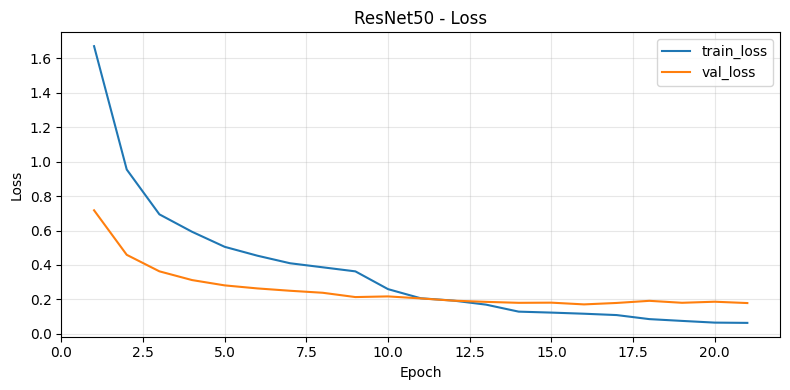

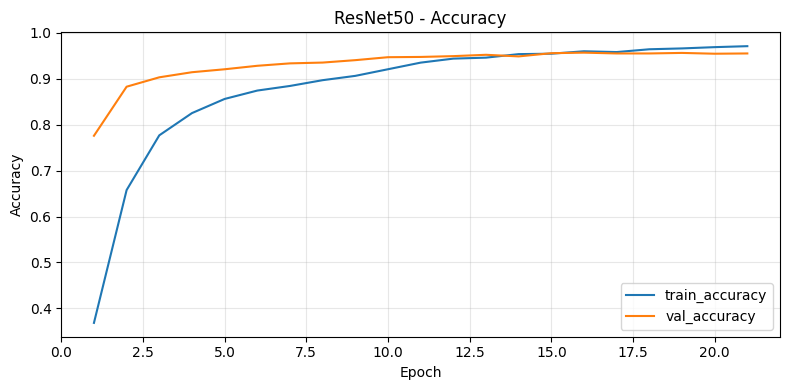

In [ ]:
STAGE2_DONE = RUN_DIR / "stage2_done.json"
STAGE2_LAST = RUN_DIR / "last_stage2.keras"
STAGE2_BEST = RUN_DIR / "best_stage2.keras"
STAGE2_HISTORY = RUN_DIR / "history_stage2.csv"

FINAL_BEST = RUN_DIR / "best_model.keras"
FINAL_LAST = RUN_DIR / "last_model.keras"

if FINAL_BEST.exists() and STAGE2_DONE.exists():
    print("[STAGE 2] Đã hoàn thành, bỏ qua.")
    model = keras.models.load_model(FINAL_BEST)

else:
    print("[STAGE 2] Bắt đầu hoặc resume fine-tune...")

    initial_epoch = count_history_epochs(STAGE2_HISTORY)

    if STAGE2_LAST.exists() and initial_epoch > 0:
        print(f"[STAGE 2] Resume từ: {STAGE2_LAST}")
        print("initial_epoch:", initial_epoch)
        model = keras.models.load_model(STAGE2_LAST)
        compile_model(model, STAGE2_LR)

    else:
        print("[STAGE 2] Load best stage 1 và mở một phần backbone.")
        assert STAGE1_BEST.exists(), f"Không tìm thấy STAGE1_BEST: {STAGE1_BEST}"

        initial_epoch = 0
        model = keras.models.load_model(STAGE1_BEST)
        model = unfreeze_for_finetune(model)
        compile_model(model, STAGE2_LR)

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=str(STAGE2_BEST),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(STAGE2_LAST),
            monitor="val_loss",
            mode="min",
            save_best_only=False,
            save_weights_only=False,
            verbose=0,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            filename=str(STAGE2_HISTORY),
            append=(initial_epoch > 0),
        ),
        keras.callbacks.TerminateOnNaN(),
    ]

    if initial_epoch < STAGE2_EPOCHS:
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=STAGE2_EPOCHS,
            initial_epoch=initial_epoch,
            class_weight=class_weights,
            callbacks=callbacks,
            verbose=1,
        )

    if STAGE2_BEST.exists():
        model = keras.models.load_model(STAGE2_BEST)
    else:
        model.save(STAGE2_BEST)

    model.save(FINAL_BEST)

    if STAGE2_LAST.exists():
        last_model = keras.models.load_model(STAGE2_LAST)
        last_model.save(FINAL_LAST)
    else:
        model.save(FINAL_LAST)

    save_json(
        {
            "model_alias": MODEL_ALIAS,
            "stage": "stage2",
            "status": "done",
            "stage2_best": str(STAGE2_BEST),
            "stage2_last": str(STAGE2_LAST),
            "final_best": str(FINAL_BEST),
            "final_last": str(FINAL_LAST),
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        },
        STAGE2_DONE
    )

    print("[STAGE 2] Hoàn thành.")

plot_history()

58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 282ms/step


,precision,recall,f1-score,support
Anthracnose,0.972115,0.972115,0.972115,1040.000000
BacterialSpot,0.957746,0.985507,0.971429,69.000000
Curl,0.981481,0.981481,0.981481,54.000000
Healthy,1.000000,0.970588,0.985075,34.000000
RingSpot,0.956113,0.954617,0.955364,639.000000
accuracy,0.966776,0.966776,0.966776,0.966776
macro avg,0.973491,0.972862,0.973093,1836.000000
weighted avg,0.966798,0.966776,0.966775,1836.000000


,Anthracnose,BacterialSpot,Curl,Healthy,RingSpot
Anthracnose,1011,1,0,0,28
BacterialSpot,0,68,1,0,0
Curl,0,1,53,0,0
Healthy,0,1,0,33,0
RingSpot,29,0,0,0,610


{
  "model_alias": "ResNet50",
  "accuracy": 0.9667755991285403,
  "macro_precision": 0.9734912395269365,
  "macro_recall": 0.9728617872374402,
  "macro_f1": 0.9730928398163581,
  "weighted_precision": 0.9667977232543127,
  "weighted_recall": 0.9667755991285403,
  "weighted_f1": 0.9667749405279682,
  "num_test_samples": 1836,
  "final_best": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN_Baselines/ResNet50/best_model.keras",
  "timestamp": "2026-04-28 13:56:06"
}


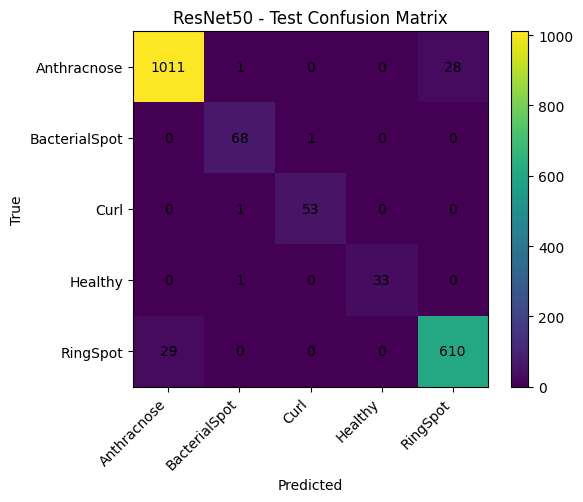

In [ ]:
FINAL_BEST = RUN_DIR / "best_model.keras"
assert FINAL_BEST.exists(), f"Không tìm thấy FINAL_BEST: {FINAL_BEST}"

model = keras.models.load_model(FINAL_BEST)

def predict_dataset(model, ds):
    y_true = np.concatenate([y.numpy() for _, y in ds], axis=0)
    y_prob = model.predict(ds, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    return y_true, y_pred, y_prob

y_true, y_pred, y_prob = predict_dataset(model, test_ds)

acc = accuracy_score(y_true, y_pred)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_df.to_csv(RUN_DIR / "test_classification_report.csv", encoding="utf-8-sig")

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
display(cm_df)

cm_df.to_csv(RUN_DIR / "test_confusion_matrix.csv", encoding="utf-8-sig")

summary = {
    "model_alias": MODEL_ALIAS,
    "accuracy": float(acc),
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_p),
    "weighted_recall": float(weighted_r),
    "weighted_f1": float(weighted_f1),
    "num_test_samples": int(len(y_true)),
    "final_best": str(FINAL_BEST),
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
}

save_json(summary, RUN_DIR / "test_summary.json")

print(json.dumps(summary, indent=2, ensure_ascii=False))

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title(f"{MODEL_ALIAS} - Test Confusion Matrix")
plt.colorbar()

ticks = np.arange(NUM_CLASSES)
plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(ticks, CLASS_NAMES)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(RUN_DIR / "test_confusion_matrix.png", dpi=200)
plt.show()